<div class="notebook-nav"><a href="https://colab.research.google.com/github/xing-mei/xing-mei.github.io/blob/master/notes/generative_modeling_journey/distribution_language.ipynb">&larr; Previous: 1. The Language of Distributions</a> &middot; <a href="https://colab.research.google.com/github/xing-mei/xing-mei.github.io/blob/master/notes/generative_modeling_journey.ipynb">Journey home</a> &middot; <a href="https://colab.research.google.com/github/xing-mei/xing-mei.github.io/blob/master/notes/generative_modeling_journey/access_matrix.ipynb">Next: 3. The Constraint Matrix &rarr;</a></div>

# 2. Measuring the Gap Between Distributions

Generative modeling asks a model law $Q$ to agree with a target law $P$. Saying that they should
"look similar" is not yet an objective. We need a scalar that detects disagreement and can actually
be computed from the information the two laws expose.

That second requirement changes everything. A formula may ask for normalized densities, scores,
samples, a learned witness, or a transport plan. Two divergences can describe the same pair of laws
while demanding completely different access and computation.

Throughout this chapter, $P$ is the target law with density $p$ when one exists, and $Q$ is the model
law with density $q$. We write $y\sim P$ for a target sample and $x\sim Q$ for a model sample.

## 1. A divergence is a question plus an access requirement

A **divergence** is a nonnegative comparison

$$
D(Q,P)\ge 0,
\qquad
D(Q,P)=0\ \Longleftrightarrow\ Q=P.
\tag{2.1}
$$

Not every divergence is symmetric, and most do not obey the triangle inequality, so "divergence" is
broader than "distance." Its job is simply to turn disagreement between two whole laws into one
number whose minimum identifies equality.

> **Why distributions instead of paired regression?** When one input has several valid targets,
> minimizing mean squared error returns their conditional mean, often producing an output between
> modes. Distribution matching does not begin from an arbitrary one-to-one pairing. It compares the
> generated and target sample sets as whole distributions, so important modes, long tails, and the
> probability assigned to each region can all enter the measurement instead of being averaged into
> one prediction.

But a mathematical definition is not automatically a usable objective. We must ask two questions:

| Family | What it compares | What must be available |
|:---|:---|:---|
| $f$-divergence | density ratios | density evaluation or a ratio estimator |
| Fisher divergence | log-density gradients | scores or a score-matching rewrite |
| Integral probability metric | expectations of witness functions | samples and a fixed or learned witness |
| Optimal transport | the cost of moving mass | samples and a coupling solver |

Every equation below defines a comparison between the **full laws**. In practice, those expectations
are estimated from finite minibatches. Even a plain sample average fluctuates from batch to batch.
When the estimator also fits a witness or solves a transport plan on that same batch, the minibatch
quantity can be systematically different from the population divergence. A small batch may miss a
mode entirely, so the computed gap can understate a disagreement that exists in the full laws.

We take the families in that order: first comparisons that read densities, then comparisons that can
be built from samples.

## 2. Density ratios: the $f$-divergence family

Let $A$ and $B$ have densities $a$ and $b$. Choose a convex function $f$ with $f(1)=0$ and define

$$
D_f(A\,\|\,B)
=
\mathbb{E}_{x\sim B}
\left[
f\!\left(\frac{a(x)}{b(x)}\right)
\right].
\tag{2.2}
$$

The ratio $a/b$ equals $1$ everywhere exactly when the densities agree. Moreover,
$\mathbb{E}_{x\sim B}[a(x)/b(x)]=1$, so Jensen's inequality gives
$D_f(A\|B)\ge f(1)=0$. The choice of $f$ decides how different regions are weighted.

### Forward KL covers mass

Set $A=P$, $B=Q$, and $f(t)=t\log t$. The factor $p/q$ moves the average from the model to the target:

$$
\mathrm{KL}(P\,\|\,Q)
=
\mathbb{E}_{x\sim Q}
\left[
\frac{p(x)}{q(x)}
\log\frac{p(x)}{q(x)}
\right]
=
\mathbb{E}_{y\sim P}
\left[
\log\frac{p(y)}{q(y)}
\right].
\tag{2.3}
$$

If $p(y)>0$ while $q(y)\to0$, the penalty diverges. Forward KL therefore resists dropping target
modes and is called **mass-covering**.

Evaluating the numerical KL requires both densities. Minimizing it over the model is cheaper:
$\mathbb{E}_{P}[\log p]$ is constant in the model parameters, so maximum likelihood needs target
samples and the model log-density $\log q(y)$, not an evaluable target density.

### Reverse KL seeks modes

Choose $f(t)=-\log t$. The average remains under the model:

$$
\mathrm{KL}(Q\,\|\,P)
=
\mathbb{E}_{x\sim Q}
\left[
\log\frac{q(x)}{p(x)}
\right].
\tag{2.4}
$$

A target mode that receives no model mass contributes nothing to this average. By contrast, model
mass placed where $p(x)$ is tiny is expensive. Reverse KL may therefore keep one sharp mode and drop
others: it is **mode-seeking**. Its raw form needs model samples together with $\log q(x)$ and
$\log p(x)$; an unnormalized target density is enough for optimization because its missing normalizer
is constant in the model parameters.

### Jensen--Shannon balances the two sides

Flip a fair coin. Draw from $P$ on one outcome and from $Q$ on the other. Call the law of the resulting
sample $M$. When densities exist, its density is

$$
m(x)=\tfrac12 p(x)+\tfrac12 q(x).
$$

Jensen--Shannon divergence compares each law to this common mixture:

$$
\mathrm{JSD}(P,Q)
=
\tfrac12\,\mathrm{KL}(P\,\|\,M)
+
\tfrac12\,\mathrm{KL}(Q\,\|\,M)
\in[0,\log 2].
\tag{2.5}
$$

JSD is symmetric and bounded. At its optimal discriminator, the
[original GAN](https://arxiv.org/abs/1406.2661) minimizes this divergence. The discriminator is a
learned density-ratio estimator, allowing JSD to be optimized from samples even though its defining
formula is written with densities.

## 3. Scores: differentiate away the normalizer

The **score** of a density is its gradient with respect to the sample:

$$
s_P(x)=\nabla_x\log p(x).
$$

If only an unnormalized density $\tilde p(x)$ is known, with
$p(x)=\tilde p(x)/Z_P$, then

$$
\nabla_x\log p(x)
=
\nabla_x\log\tilde p(x),
$$

because the constant $Z_P$ disappears under $\nabla_x$. Fisher divergence compares two laws through
these local slopes:

$$
\mathrm{Fisher}(P\,\|\,Q)
=
\mathbb{E}_{y\sim P}
\left[
\left\|
\nabla_y\log p(y)-\nabla_y\log q(y)
\right\|^2
\right].
\tag{2.6}
$$

The direct formula needs target samples and both scores. Score matching rewrites the objective so the
unknown target score disappears; denoising score matching makes that rewrite practical by perturbing
the data with known noise. This is why Fisher divergence is native to diffusion models. The classical
connection is [Hyvärinen's score-matching identity](https://www.jmlr.org/papers/v6/hyvarinen05a.html).

## 4. Witness functions: compare expectations from samples

An **integral probability metric** (IPM) chooses a class $\mathcal F$ of scalar test functions and asks
which member most separates the two laws:

$$
\operatorname{IPM}_{\mathcal F}(Q,P)
=
\sup_{f\in\mathcal F}
\left(
\mathbb{E}_{x\sim Q}[f(x)]
-
\mathbb{E}_{y\sim P}[f(y)]
\right).
\tag{2.7}
$$

The winning $f^\star$ is a **witness**: one statistic whose average exposes the disagreement. Samples
are enough to estimate both expectations. The choice of $\mathcal F$ decides how the witness is found.

### Maximum mean discrepancy

Let $\mathcal F$ be the unit ball induced by a positive-definite kernel $k$. The supremum then has a
closed form, the [maximum mean discrepancy](https://arxiv.org/abs/0805.2368):

$$
\begin{aligned}
\operatorname{MMD}^2(Q,P)
&=
\mathbb{E}_{x,x'\sim Q}[k(x,x')]
-2\mathbb{E}_{x\sim Q,\,y\sim P}[k(x,y)]\\
&\quad+
\mathbb{E}_{y,y'\sim P}[k(y,y')].
\end{aligned}
\tag{2.8}
$$

Here $x,x'$ are independent model draws and $y,y'$ independent target draws. A batch estimate evaluates
all self and cross pairs, costing $O(N^2)$. It is smooth in the sample locations and therefore usable
as a differentiable loss.

### Energy distance

The distance kernel $k(x,y)=-\|x-y\|$ gives the
[energy distance](https://arxiv.org/abs/1207.6076):

$$
\mathcal E(Q,P)
=
2\mathbb{E}_{x\sim Q,\,y\sim P}\|x-y\|
-
\mathbb{E}_{x,x'\sim Q}\|x-x'\|
-
\mathbb{E}_{y,y'\sim P}\|y-y'\|.
\tag{2.9}
$$

It has the same $O(N^2)$ pairwise cost but no kernel bandwidth to choose, making it a convenient
sample-only diagnostic.

### A neural witness

Instead of fixing a kernel, we can let a neural network represent the witness and train it to enlarge
the expectation gap. The [Wasserstein GAN](https://arxiv.org/abs/1701.07875) uses a constrained neural
critic in exactly this IPM role. A learned witness can be much sharper than a fixed kernel, but it adds
an inner optimization and turns training into a delicate min-max problem.

This is different from the original GAN above: its classifier estimates a density ratio and recovers
JSD, while the Wasserstein critic directly maximizes an expectation difference.

> **Geometry is part of the comparison.** An IPM does not always write a distance between two samples
> explicitly, but its function class still decides which changes count as nearby: an RBF kernel uses
> Euclidean distance, energy distance uses it directly, and a Lipschitz critic is Lipschitz relative to
> a chosen metric. On high-dimensional data such as images or videos, raw pixel distance may not track
> semantic similarity. Computing the comparison in a learned feature or latent space can help, but then
> that representation supplies the geometry and becomes part of the definition.

## 5. Transport plans: pay for moving mass

Optimal transport makes the geometry choice explicit. A **coupling**
$\gamma\in\Pi(Q,P)$ is a joint law on pairs $(x,y)$ whose marginals are $Q$ and $P$. It records how much
model mass at $x$ is assigned to target mass at $y$. Given a ground cost $c(x,y)$,

$$
\operatorname{OT}_c(Q,P)
=
\inf_{\gamma\in\Pi(Q,P)}
\mathbb{E}_{(x,y)\sim\gamma}[c(x,y)].
\tag{2.10}
$$

The coupling is not assumed to be part of the data. The optimization searches for the cheapest one.
The result is meaningful only when the ground cost is meaningful: Euclidean distance is natural for
our two-dimensional toy, but pixelwise distance can call two perceptually similar images far apart and
two semantically different videos close. Practical image and video transport therefore often uses a
feature-space, latent-space, or perceptual ground cost instead of raw pixels.

### Wasserstein distance

With $c(x,y)=\|x-y\|^p$,

$$
W_p(Q,P)
=
\left(
\inf_{\gamma\in\Pi(Q,P)}
\mathbb{E}_{(x,y)\sim\gamma}\|x-y\|^p
\right)^{1/p}.
\tag{2.11}
$$

This distance respects geometry: moving mass farther costs more. For empirical measures, however,
finding the exact plan is a linear program whose cost grows poorly with sample count. At $p=1$,
Kantorovich--Rubinstein duality gives the same quantity as the IPM over all $1$-Lipschitz witnesses;
the transport and witness views are two sides of the same comparison.

### Sliced Wasserstein

In one dimension the optimal plan is obtained by sorting. Sliced Wasserstein projects the two laws
onto random lines, solves those one-dimensional problems, and averages:

$$
\operatorname{SW}_p(Q,P)
=
\left(
\mathbb{E}_{v}
\left[
W_p^p(\pi_v Q,\pi_v P)
\right]
\right)^{1/p},
\tag{2.12}
$$

where $v$ is uniform on the unit sphere and $\pi_v Q$ is the law of
$\langle v,x\rangle$ for $x\sim Q$. Each projection costs an $O(N\log N)$ sort. The tradeoff is that
many random projections may be needed before the average represents high-dimensional geometry well.

### Sinkhorn divergence

Entropy regularization replaces the expensive exact transport problem by a sequence of matrix
rescalings. Define

$$
\operatorname{OT}^{\varepsilon}_c(Q,P)
=
\min_{\gamma\in\Pi(Q,P)}
\mathbb{E}_{(x,y)\sim\gamma}[c(x,y)]
+
\varepsilon\,
\mathrm{KL}\!\left(\gamma\,\middle\|\,Q\otimes P\right).
\tag{2.13}
$$

The penalty forces the empirical plan into the form
$\gamma_{ij}\propto u_i e^{-c_{ij}/\varepsilon}v_j$. Alternately rescaling its rows and columns until
both marginals are correct gives the [Sinkhorn algorithm](https://arxiv.org/abs/1306.0895), a
differentiable sequence of $O(N^2)$ matrix operations.

Regularized transport is biased even when its two arguments agree. The Sinkhorn divergence removes
that bias:

$$
\mathrm S_\varepsilon(Q,P)
=
\underbrace{\operatorname{OT}^{\varepsilon}_c(Q,P)}_{\text{cross: attraction}}
-
\underbrace{
\left(
\tfrac12\operatorname{OT}^{\varepsilon}_c(Q,Q)
+
\tfrac12\operatorname{OT}^{\varepsilon}_c(P,P)
\right)
}_{\text{self terms: repulsion}}.
\tag{2.14}
$$

The result is zero when $Q=P$. With the Euclidean ground cost used below,
$\varepsilon\to0$ approaches exact transport, while large $\varepsilon$ approaches an energy/MMD-like
comparison. It therefore bridges geometric transport and kernel discrepancies
([Genevay et al., 2018](https://arxiv.org/abs/1706.00292);
[Feydy et al., 2019](https://arxiv.org/abs/1810.08278)).

The following code gathers representative closed forms and sample estimators. These functions are
included directly in this notebook, so the chapter remains runnable by itself in Colab.

In [1]:
from __future__ import annotations
import math
import numpy as np
import torch
import matplotlib.pyplot as plt

torch.manual_seed(0)
np.random.seed(0)

In [2]:
def kl_gauss(mu_q, mu_p, sigma=1.0):
    '''KL for equal-covariance isotropic Gaussians.'''
    d = torch.as_tensor(mu_q, dtype=torch.float) - torch.as_tensor(mu_p, dtype=torch.float)
    return d.dot(d) / (2 * sigma**2)


def fisher_gauss(mu_q, mu_p, sigma=1.0):
    '''Fisher divergence for equal-covariance isotropic Gaussians.'''
    d = torch.as_tensor(mu_q, dtype=torch.float) - torch.as_tensor(mu_p, dtype=torch.float)
    return d.dot(d) / sigma**4


def w2_gauss(mu_q, mu_p):
    '''2-Wasserstein distance for equal-covariance Gaussians.'''
    d = torch.as_tensor(mu_q, dtype=torch.float) - torch.as_tensor(mu_p, dtype=torch.float)
    return d.norm()


def mmd2(x, y, sigmas=(0.5, 1.0, 2.0, 4.0, 8.0)):
    '''Biased multi-bandwidth RBF maximum mean discrepancy squared.'''
    def kernel(d2):
        return sum(torch.exp(-d2 / (2 * sigma**2)) for sigma in sigmas)

    return (
        kernel(torch.cdist(x, x).square()).mean()
        + kernel(torch.cdist(y, y).square()).mean()
        - 2 * kernel(torch.cdist(x, y).square()).mean()
    )


def energy_distance(x, y):
    '''Energy distance between two sample batches.'''
    mean_distance = lambda a, b: torch.cdist(a, b).mean()
    return 2 * mean_distance(x, y) - mean_distance(x, x) - mean_distance(y, y)


def sliced_w2_squared(x, y, n_proj=128):
    '''Mean squared 1D Wasserstein distance over random projections.'''
    if x.ndim != 2 or y.ndim != 2 or x.shape[1] != y.shape[1]:
        raise ValueError("x and y must be two-dimensional batches with the same feature dimension")
    if x.shape[0] != y.shape[0]:
        raise ValueError("sliced_w2_squared requires equally sized batches")

    directions = torch.randn(
        x.shape[1],
        n_proj,
        dtype=x.dtype,
        device=x.device,
    )
    directions = directions / directions.norm(dim=0, keepdim=True)
    x_projected = (x @ directions).sort(dim=0).values
    y_projected = (y @ directions).sort(dim=0).values
    return (x_projected - y_projected).square().mean()


def sinkhorn_divergence(x, y, eps=1.0, n_iter=40):
    '''Debiased entropic OT with Euclidean ground cost, solved in the log domain.'''
    if eps <= 0:
        raise ValueError("eps must be positive")
    if n_iter <= 0:
        raise ValueError("n_iter must be positive")

    def regularized_ot(a, b):
        cost = torch.cdist(a, b)
        n, m = cost.shape
        f = a.new_zeros(n)
        g = b.new_zeros(m)
        for _ in range(n_iter):
            f = -eps * torch.logsumexp(
                (g[None, :] - cost) / eps - math.log(m),
                dim=1,
            )
            g = -eps * torch.logsumexp(
                (f[:, None] - cost) / eps - math.log(n),
                dim=0,
            )
        return f.mean() + g.mean()

    return (
        regularized_ot(x, y)
        - 0.5 * regularized_ot(x, x)
        - 0.5 * regularized_ot(y, y)
    )

## 6. One disagreement, seven readings

We now translate one Gaussian cloud while keeping its covariance fixed. The target is
$P=\mathcal N(0,I)$ and the model is $Q_g=\mathcal N((g,0),I)$. As the mean gap $g$ shrinks, the laws
approach one another.

The density and score rows have closed forms for this special toy. The remaining rows see only finite
sample clouds. Their numerical scales are unrelated, so the values should not be compared vertically.
The meaningful common statement is horizontal: every measure decreases as the same disagreement is
removed.

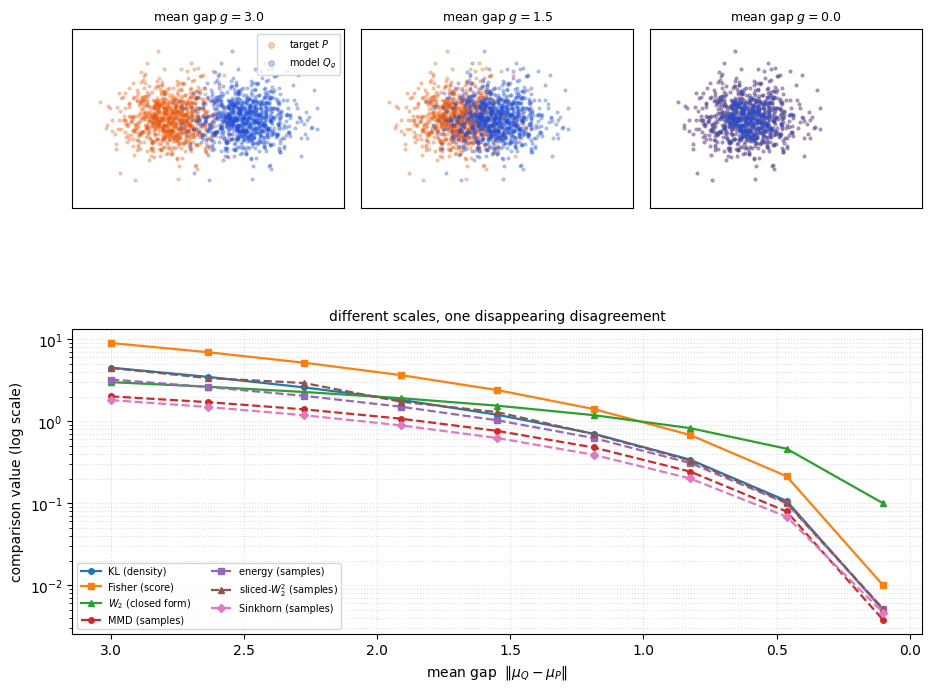

values at mean gap 3.0:
{'KL (density)': 4.5, 'Fisher (score)': 9.0, '$W_2$ (closed form)': 3.0, 'MMD (samples)': 2.011, 'energy (samples)': 3.229, 'sliced-$W_2^2$ (samples)': 4.462, 'Sinkhorn (samples)': 1.813}
values at mean gap 0.1:
{'KL (density)': 0.005, 'Fisher (score)': 0.01, '$W_2$ (closed form)': 0.1, 'MMD (samples)': 0.0038, 'energy (samples)': 0.0051, 'sliced-$W_2^2$ (samples)': 0.0052, 'Sinkhorn (samples)': 0.0046}


In [3]:
SIGMA, N = 1.0, 384
mu_p = [0.0, 0.0]
gaps = torch.linspace(3.0, 0.1, 9)

# Reuse one empirical cloud and translate it. This isolates the changing mean gap instead of adding
# a fresh Monte Carlo fluctuation at every horizontal position.
target_samples = SIGMA * torch.randn(N, 2)

names = [
    "KL (density)",
    "Fisher (score)",
    "$W_2$ (closed form)",
    "MMD (samples)",
    "energy (samples)",
    "sliced-$W_2^2$ (samples)",
    "Sinkhorn (samples)",
]
curves = {name: [] for name in names}

for gap in gaps:
    mu_q = [float(gap), 0.0]
    model_samples = target_samples + torch.tensor(mu_q)
    curves["KL (density)"].append(kl_gauss(mu_q, mu_p, SIGMA).item())
    curves["Fisher (score)"].append(fisher_gauss(mu_q, mu_p, SIGMA).item())
    curves["$W_2$ (closed form)"].append(w2_gauss(mu_q, mu_p).item())
    curves["MMD (samples)"].append(mmd2(model_samples, target_samples).item())
    curves["energy (samples)"].append(energy_distance(model_samples, target_samples).item())
    curves["sliced-$W_2^2$ (samples)"].append(
        sliced_w2_squared(model_samples, target_samples).item()
    )
    curves["Sinkhorn (samples)"].append(
        sinkhorn_divergence(model_samples, target_samples, eps=1.0, n_iter=40).item()
    )

fig = plt.figure(figsize=(9.2, 6.8), constrained_layout=True)
grid = fig.add_gridspec(2, 3, height_ratios=[1.0, 1.7], hspace=0.30)
display_base = SIGMA * torch.randn(900, 2)
for j, gap in enumerate([3.0, 1.5, 0.0]):
    ax = fig.add_subplot(grid[0, j])
    target = display_base.numpy()
    model = (display_base + torch.tensor([gap, 0.0])).numpy()
    ax.scatter(target[:, 0], target[:, 1], s=4, alpha=0.28, color="#ea580c", label="target $P$")
    ax.scatter(model[:, 0], model[:, 1], s=4, alpha=0.28, color="#1d4ed8", label="model $Q_g$")
    ax.set_title(f"mean gap $g={gap:.1f}$", fontsize=9)
    ax.set_xlim(-4, 7)
    ax.set_ylim(-5, 5)
    ax.set_xticks([])
    ax.set_yticks([])
    if j == 0:
        ax.legend(fontsize=7, markerscale=2, loc="upper right")

curve_ax = fig.add_subplot(grid[1, :])
styles = ["-o", "-s", "-^", "--o", "--s", "--^", "--D"]
for name, style, color in zip(names, styles, plt.cm.tab10.colors):
    curve_ax.semilogy(gaps.numpy(), curves[name], style, color=color, ms=4, lw=1.6, label=name)
curve_ax.invert_xaxis()
curve_ax.grid(True, which="both", ls=":", alpha=0.4)
curve_ax.set_xlabel(r"mean gap  $\|\mu_Q-\mu_P\|$")
curve_ax.set_ylabel("comparison value (log scale)")
curve_ax.set_title("different scales, one disappearing disagreement", fontsize=10)
curve_ax.legend(fontsize=7, ncol=2, loc="lower left")
plt.show()

print("values at mean gap 3.0:")
print({name: round(curves[name][0], 3) for name in names})
print("values at mean gap 0.1:")
print({name: round(curves[name][-1], 4) for name in names})

## 7. The access and computation bill

The definitions become useful only after we identify a legal estimator:

| Comparison | What the computable form needs | Per-batch cost | Training shape |
|:---|:---|:---|:---|
| Forward KL | target samples and model log-density | $O(N)$ | ordinary minimization |
| Reverse KL | model samples, model density, target energy/density | $O(N)$ | ordinary minimization |
| JSD through a GAN | samples from both sides and a classifier | $O(N)$ per pass | min-max |
| Fisher / score | samples and scores, or a score-matching rewrite | $O(N)$ | ordinary minimization |
| MMD / energy | samples from both sides | $O(N^2)$ pairs | ordinary minimization |
| Neural IPM | samples from both sides and a critic | $O(N)$ per pass | min-max |
| Exact / sliced Wasserstein | samples and a coupling solver / projections | LP / $O(RN\log N)$ | ordinary minimization |
| Sinkhorn divergence | samples and $K$ matrix-rescaling iterations | $O(KN^2)$ | ordinary minimization |

Nothing here is included only for completeness. Forward KL returns with density models; JSD, MMD,
sliced Wasserstein, and Sinkhorn divergence return with sample-only pretraining; energy distance is
both a diagnostic and the source of a drifting field; Fisher divergence returns with diffusion;
reverse KL with RL post-training and distillation; and Wasserstein geometry with coupling and flow
arguments.

There is no universally best row. A divergence is useful only when its required information exists,
its geometry matches the sample space, and its minibatch estimator fits the computation budget.

<div class="notebook-footer"><a href="https://colab.research.google.com/github/xing-mei/xing-mei.github.io/blob/master/notes/generative_modeling_journey.ipynb">Generative Modeling: A Gentle Journey with Distribution Matching</a> &middot; Chapter 2 of 20</div>